In [2]:
import pandas as pd
df_certified_latest= pd.read_csv("D:\\Projects\\B-Crop-Social-Impact\\data\\processed\\bcorp_certified_latest.csv")

In [3]:
print(df_certified_latest.shape)
print(df_certified_latest.head())

(7039, 19)
           company_id             company_name current_status  overall_score  \
0  0013b00001nDrJIAA0  Agency Brand Management      certified          100.1   
1  0013b00001nDrNrAAK                  Arbonne      certified          119.9   
2  0013b00001nDrfVAAS     Just Made Foods, LLC      certified           81.2   
3  0013b00001nDs3IAAS           Chemistry Team      certified           86.8   
4  0013b00001nDsaMAAS     The Makers Food GmbH      certified           99.5   

  date_first_certified                    date_certified  \
0           2019-11-18  2023-06-20 07:04:04.714357+00:00   
1           2019-12-30  2023-01-23 12:35:41.870097+00:00   
2           2019-09-11  2019-09-11 16:59:06.150041+00:00   
3           2021-06-30  2021-06-30 03:17:05.014506+00:00   
4           2021-10-20  2021-10-20 13:06:17.333702+00:00   

                        industry                  industry_category  \
0  Advertising & market research  Professional & technical services   
1    

In [4]:
print(df_certified_latest.isnull().sum().sort_values(ascending=False))

products_and_services      3230
impact_area_workers         592
impact_area_customers        87
state                         3
current_status                0
company_id                    0
company_name                  0
industry                      0
date_certified                0
overall_score                 0
date_first_certified          0
country                       0
industry_category             0
city                          0
sector                        0
impact_area_community         0
size                          0
impact_area_environment       0
impact_area_governance        0
dtype: int64


In [5]:
print(df_certified_latest["country"].value_counts().head(10))

country
United States      1793
United Kingdom     1516
Canada              467
Australia           452
France              325
Brazil              264
Italy               246
Netherlands The     236
Chile               206
Argentina           193
Name: count, dtype: int64


In [6]:
print(df_certified_latest["industry_category"].value_counts().head(10))

industry_category
Professional & technical services          1721
Retail                                      921
Manufactured Goods                          859
Information, communication & technology     701
Financial & insurance activities            589
Wholesale                                   568
Real estate, design & building              237
Agriculture, forestry & fishing             229
Other services                              226
Administrative & support services           197
Name: count, dtype: int64


In [7]:
print(df_certified_latest["size"].value_counts())

size
10-49      2575
1-9        2324
50-249     1070
0           592
250-999     353
1000+       125
Name: count, dtype: int64


In [8]:
print(df_certified_latest["overall_score"].describe())

count    7039.000000
mean       95.074826
std        14.589991
min        78.200000
25%        84.300000
50%        90.900000
75%       101.400000
max       206.700000
Name: overall_score, dtype: float64


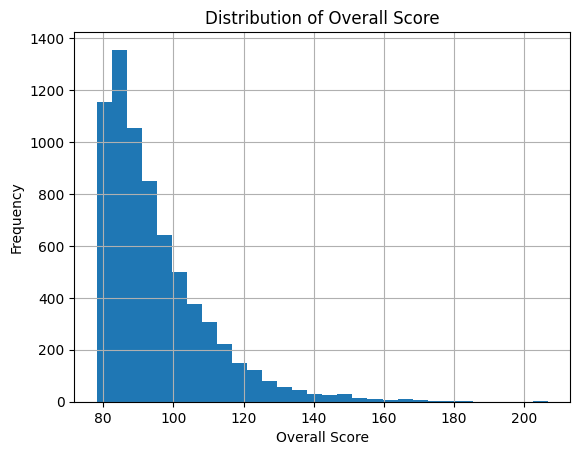

In [9]:
import matplotlib.pyplot as plt

df_certified_latest["overall_score"].hist(bins=30)
plt.xlabel("Overall Score")
plt.ylabel("Frequency")
plt.title("Distribution of Overall Score")
plt.show()

In [10]:
df_certified_latest["date_first_certified"] = pd.to_datetime(df_certified_latest["date_first_certified"], format='mixed')
df_certified_latest["date_certified"] = pd.to_datetime(df_certified_latest["date_certified"], format='mixed')

df_certified_latest["first_cert_year"] = df_certified_latest["date_first_certified"].dt.year
df_certified_latest["certified_year"] = df_certified_latest["date_certified"].dt.year

today = pd.Timestamp.today()
df_certified_latest["years_since_first_certification"] = (
    (today - df_certified_latest["date_first_certified"]).dt.days / 365.25
).round(1)

df_certified_latest["score_band"] = pd.cut(
    df_certified_latest["overall_score"],
    bins=[0, 80, 90, 100, 120, 200],
    labels=["Below 80", "80-89.9", "90-99.9", "100-119.9", "120+"]
)

In [11]:
print(df_certified_latest[["date_first_certified", "date_certified"]].dtypes)
print(df_certified_latest[["date_first_certified", "date_certified", "first_cert_year", "certified_year"]].head())

date_first_certified         datetime64[us]
date_certified          datetime64[us, UTC]
dtype: object
  date_first_certified                   date_certified  first_cert_year  \
0           2019-11-18 2023-06-20 07:04:04.714357+00:00             2019   
1           2019-12-30 2023-01-23 12:35:41.870097+00:00             2019   
2           2019-09-11 2019-09-11 16:59:06.150041+00:00             2019   
3           2021-06-30 2021-06-30 03:17:05.014506+00:00             2021   
4           2021-10-20 2021-10-20 13:06:17.333702+00:00             2021   

   certified_year  
0            2023  
1            2023  
2            2019  
3            2021  
4            2021  


In [12]:
print(df_certified_latest[[
    "date_first_certified",
    "date_certified",
    "first_cert_year",
    "certified_year",
    "years_since_first_certification",
    "score_band"
]].head())

  date_first_certified                   date_certified  first_cert_year  \
0           2019-11-18 2023-06-20 07:04:04.714357+00:00             2019   
1           2019-12-30 2023-01-23 12:35:41.870097+00:00             2019   
2           2019-09-11 2019-09-11 16:59:06.150041+00:00             2019   
3           2021-06-30 2021-06-30 03:17:05.014506+00:00             2021   
4           2021-10-20 2021-10-20 13:06:17.333702+00:00             2021   

   certified_year  years_since_first_certification score_band  
0            2023                              6.3  100-119.9  
1            2023                              6.2  100-119.9  
2            2019                              6.5    80-89.9  
3            2021                              4.7    80-89.9  
4            2021                              4.4    90-99.9  


In [13]:
print(df_certified_latest["score_band"].value_counts(dropna=False))
print(df_certified_latest.groupby("industry_category")["overall_score"].mean().sort_values(ascending=False).head(10))
print(df_certified_latest.groupby("country")["overall_score"].mean().sort_values(ascending=False).head(10))
print(df_certified_latest[[
    "impact_area_community",
    "impact_area_customers",
    "impact_area_environment",
    "impact_area_governance",
    "impact_area_workers"
]].mean().sort_values(ascending=False))

score_band
80-89.9      3256
90-99.9      1790
100-119.9    1462
120+          468
Below 80       62
NaN             1
Name: count, dtype: int64
industry_category
Energy, Heating & Cooling            116.530769
Water & Sewerage                     102.020000
Financial & insurance activities     101.712224
Education                             98.817610
Human health & social work            98.380000
Energy                                97.617949
Construction                          97.478947
Waste Management & Recycling          97.333333
Real estate, design & building        97.185654
Professional & technical services     95.997618
Name: overall_score, dtype: float64
country
Zambia         154.800000
Sri Lanka      117.800000
Afghanistan    116.900000
Serbia         113.500000
Madagascar     113.166667
Senegal        111.900000
Ghana          109.800000
Egypt          109.400000
Cyprus         108.400000
Rwanda         107.000000
Name: overall_score, dtype: float64
impact_area_worke

In [14]:
df_certified_latest[df_certified_latest["score_band"].isna()][["company_id", "company_name", "overall_score"]]

,company_id,company_name,overall_score
4337,001C0000014xUPqIAM,Dr. Bronner's,206.7


In [19]:
df_certified_latest = df_certified_latest.dropna(subset=["overall_score"]).copy()

In [20]:
df_certified_latest["score_band"] = pd.cut(
    df_certified_latest["overall_score"],
    bins=[0, 80, 90, 100, 120, float("inf")],
    labels=["Below 80", "80-89.9", "90-99.9", "100-119.9", "120+"]
)

In [21]:
df_certified_latest[df_certified_latest["score_band"].isna()][["company_id", "company_name", "overall_score"]]

,company_id,company_name,overall_score


In [23]:
df_certified_latest.to_csv("D:\\Projects\\B-Crop-Social-Impact\\data\\processed\\bcorp_certified_latest_tableau.csv", index=False)